(1500, 1000, 3)


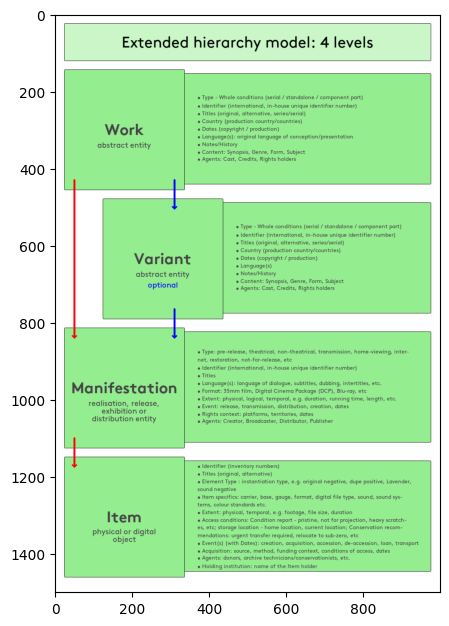

In [81]:
# notebook to work on opencv diagrams for FIAF cat manual.

# TODO, this needs a full rewrite - source data (text, colour) exists as JSON
# then, as text blocks, precomute footprint and adjust.

import cv2
import matplotlib.pylab as plt
import numpy
import pandas
import pathlib
import skimage
from PIL import Image, ImageDraw, ImageFont

def font(weight, size):

    ''' Define a font object. '''

    font_path = pathlib.Path.cwd().parents[0] / 'font' / f'BrownStd{weight}.otf'
    if not font_path.exists():
        raise Exception('Font OTF does not exist.')
    
    return ImageFont.truetype(str(font_path), size)

def draw_rectangle(name, x, y, w, h, colour):
    
    ''' Define a rectangle shape. '''

    cv2.rectangle(canvas, (x, y), (x+w, y+h), (0,0,0), 2) 
    cv2.rectangle(canvas, (x, y), (x+w, y+h), colour, -1) 
    elements[name] = {'x':x, 'y':y, 'w':w, 'h':h}



def draw_text_by_anchor(anchor, text, text_weight, text_size, center, y_offset_iterate, x_offset_manual, colour, opacity, manual_y):

    font_object = font(text_weight, text_size)
    anchor_coords = elements[anchor]
    center_x = anchor_coords['x']+(anchor_coords['w']/2)
    center_y = anchor_coords['y']+(anchor_coords['h']/2)

    text_bbox = font_object.getbbox(text[:4])
    center_y = center_y-(text_bbox[3]/2)

    center_y = center_y + (y_offset_iterate*20)

    center_x = center_x+x_offset_manual

    if center:
        text_bbox = font_object.getbbox(text)
        center_x = center_x-(text_bbox[2]/2)

    center_y = center_y+manual_y 

    detect = font_object.getbbox(text) 

    x1 = int(center_x) + detect[0]
    y1 = int(center_y) + detect[1]
    x2 = int(center_x) + detect[2]
    y2 = int(center_y) + detect[3]
    # print(bbox)

    bbox = (x1,y1,x2,y2)
    # draw.rectangle(bbox, outline='#ff0000')

    if opacity:
        draw.text((int(center_x), int(center_y)), text, font=font_object, fill=colour)

    return bbox

def render_preview(path):

    preview = cv2.cvtColor(cv2.imread(path, -1), cv2.COLOR_BGR2RGB) 
    print(preview.shape)
    plt.figure(figsize=(7.5,7.5))
    plt.imshow(skimage.img_as_float32(preview))
    plt.show()  

img_path = pathlib.Path.cwd() / '0.2.1-A.png'

canvas_w, canvas_h = 1000, 1500
canvas = numpy.zeros((canvas_h, canvas_w, 3), numpy.uint8)
canvas[:, :] = (255, 255, 255)

elements = dict()
draw_rectangle('header', 25, 25, 950, 95, ((144/2)+(255/2), (238/2)+(255/2), (148/2)+(255/2)))

box_colour = (144, 238, 148)

draw_rectangle('layer_1', 125, 155, 850, 285, box_colour)
draw_rectangle('layer_2', 125, 490, 850, 285, box_colour)
draw_rectangle('layer_3', 125, 825, 850, 285, box_colour)
draw_rectangle('layer_4', 125, 1160, 850, 285, box_colour)


draw_rectangle('box_1', 25, 145, 310, 310, box_colour)
draw_rectangle('box_2', 125, 480, 310, 310, box_colour)
draw_rectangle('box_3', 25, 815, 310, 310, box_colour)
draw_rectangle('box_4', 25, 1150, 310, 310, box_colour)

# TODO and dotted line for blue.

cv2.line(canvas, (25+25,(145+310)-25), (25+25, 815+25), (0,0,255), 4)
cv2.arrowedLine(canvas, (25+25,(480+310)-25), (25+25, 815+25), (0,0,255), 4)
cv2.arrowedLine(canvas, (25+25,(815+310)-25), (25+25, 1150+25), (0,0,255), 4)
cv2.arrowedLine(canvas, (310,(145+310)-25), (310, 480+25), (255,0,0), 4)
cv2.arrowedLine(canvas, (310,(480+310)-25), (310, 815+25), (255,0,0), 4)

cv2.imwrite(img_path, canvas)

image_data = Image.open(img_path)
draw = ImageDraw.Draw(image_data)

draw_text_by_anchor('header', 'Extended hierarchy model: 4 levels', 'Regular', 40, True, 0, 0, "#000000", 1, 0)

# mathematically calculate offsets.

layer_1_text = ['• Type - Whole conditions (serial / standalone / component part)',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles (original, alternative, series/serial)',
    '• Country (production country/countries)',
    '• Dates (copyright / production)',
    '• Language(s): original language of conception/presentation',
    '• Notes/History',
    '• Content: Synopsis, Genre, Form, Subject',
    '• Agents: Cast, Credits, Rights holders']

layer_1_text = [{'text':x, 'offset':i-((len(layer_1_text)-1)/2)} for i,x in enumerate(layer_1_text)]
for x in layer_1_text:
    draw_text_by_anchor('layer_1', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

layer_2_text = [
    '• Type - Whole conditions (serial / standalone / component part)',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles (original, alternative, series/serial)',
    '• Country (production country/countries)',
    '• Dates (copyright / production)',
    '• Language(s)',
    '• Notes/History',
    '• Content: Synopsis, Genre, Form, Subject',
    '• Agents: Cast, Credits, Rights holders'
]

layer_2_text = [{'text':x, 'offset':i-((len(layer_2_text)-1)/2)} for i,x in enumerate(layer_2_text)]
for x in layer_2_text:
    draw_text_by_anchor('layer_2', x['text'], 'Regular', 14, False, x['offset'], -80, "#444444", 1, 0)

layer_3_text = [
    '• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing, inter-',
    'net, restoration, not-for-release, etc',
    '• Identifier (international, in-house unique identifier number)',
    '• Titles',
    '• Language(s): language of dialogue, subtitles, dubbing, intertitles, etc.',
    '• Format: 35mm film, Digital Cinema Package (DCP), Blu-ray, etc',
    '• Extent: physical, logical, temporal, e.g. duration, running time, length, etc.',
    '• Event: release, transmission, distribution, creation, dates',
    '• Rights context: platforms, territories, dates',
    '• Agents: Creator, Broadcaster, Distributor, Publisher'
]

layer_3_text = [{'text':x, 'offset':i-((len(layer_3_text)-1)/2)} for i,x in enumerate(layer_3_text)]
for x in layer_3_text:
    draw_text_by_anchor('layer_3', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

layer_4_text = [
    '• Identifier (inventory numbers)',
    '• Titles (original, alternative)',
    '• Element Type : instantiation type, e.g. original negative, dupe positive, Lavender,',
    'sound negative',
    '• Item specifics: carrier, base, gauge, format, digital file type, sound, sound sys-',
    'tems, colour standards etc.',
    '• Extent: physical, temporal, e.g. footage, file size, duration',
    '• Access conditions: Condition report - pristine, not for projection, heavy scratch-',
    'es, etc; storage location - home location, current location; Conservation recom-',
    'mendations: urgent transfer required, relocate to sub-zero, etc',
    '• Event(s) (with Dates): creation, acquisition, accession, de-accession, loan, transport',
    '• Acquisition: source, method, funding context, conditions of access, dates',
    '• Agents: donors, archive technicians/conservationists, etc.',
    '• Holding institution: name of the Item holder'
]

layer_4_text = [{'text':x, 'offset':i-((len(layer_4_text)-1)/2)} for i,x in enumerate(layer_4_text)]
for x in layer_4_text:
    draw_text_by_anchor('layer_4', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

draw_text_by_anchor('box_1', 'Work', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_1', 'abstract entity', 'Regular', 20, True, 2, 0, "#444444", 1, 0)

draw_text_by_anchor('box_2', 'Variant', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_2', 'abstract entity', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_2', 'optional', 'Regular', 20, True, 3.5, 0, "blue", 1, 0)

draw_text_by_anchor('box_3', 'Manifestation', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_3', 'realisation, release,', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_3', 'exhibition or', 'Regular', 20, True, 3, 0, "#444444", 1, 0)
draw_text_by_anchor('box_3', 'distribution entity', 'Regular', 20, True, 4, 0, "#444444", 1, 0)

draw_text_by_anchor('box_4', 'Item', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'physical or digital', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'object', 'Regular', 20, True, 3, 0, "#444444", 1, 0)

image_data.save(img_path)

render_preview(img_path)

(1500, 1000, 3)


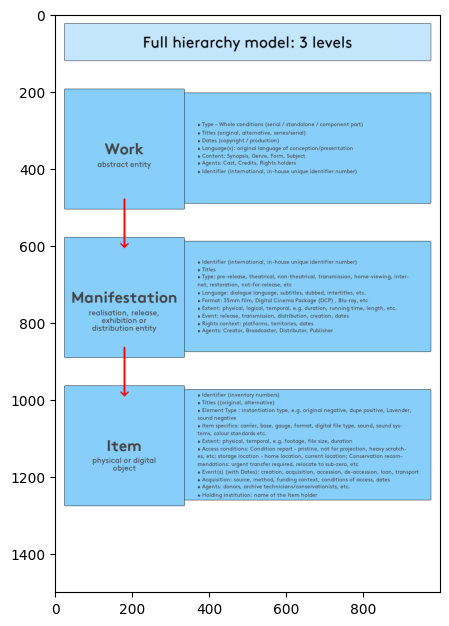

In [85]:

img_path = pathlib.Path.cwd() / '0.2.1-B.png'

canvas_w, canvas_h = 1000, 1500
canvas = numpy.zeros((canvas_h, canvas_w, 3), numpy.uint8)
canvas[:, :] = (255, 255, 255)

elements = dict()
draw_rectangle('header', 25, 25, 950, 95, ((250/2)+(255/2),(206/2)+(255/2),(135/2)+(255/2)))

box_colour = (250, 206, 135)
# 135, 206, 250

draw_rectangle('layer_1', 125, 155+50, 850, 285, box_colour)
# draw_rectangle('layer_2', 125, 490, 850, 285, box_colour)
draw_rectangle('layer_3', 125, 490+(50*2), 850, 285, box_colour)
draw_rectangle('layer_4', 125, 825+(50*3), 850, 285, box_colour)

# draw_rectangle('box_1_shadow', 25+5, 145+5, 300, 300, (0, 0, 0))

draw_rectangle('box_1', 25, 145+50, 310, 310, box_colour)
# draw_rectangle('box_2', 125, 480, 310, 310, box_colour)
draw_rectangle('box_3', 25, 480+50+50, 310, 310, box_colour)
draw_rectangle('box_4', 25, 815+50+50+50, 310, 310, box_colour)

# TODO and dotted line for blue.

# cv2.line(canvas, (25+25,(145+310)-25), (25+25, 815+25), (0,0,255), 4)
instep = 25+int(310/2)
cv2.arrowedLine(canvas, (instep,(145+50+310)-25), (instep, 480+50+50+25), (0,0,255), 4)
cv2.arrowedLine(canvas, (instep,(480+50+50+310)-25), (instep, 815+50+50+50+25), (0,0,255), 4)



# cv2.arrowedLine(canvas, (instep,(815+310)-25), (instep, 1150+25), (0,0,255), 4)
# cv2.arrowedLine(canvas, (310,(145+310)-25), (310, 480+25), (255,0,0), 4)
# cv2.arrowedLine(canvas, (310,(480+310)-25), (310, 815+25), (255,0,0), 4)

cv2.imwrite(img_path, canvas)

image_data = Image.open(img_path)
draw = ImageDraw.Draw(image_data)

draw_text_by_anchor('header', 'Full hierarchy model: 3 levels', 'Regular', 40, True, 0, 0, "#000000", 1, 0)

# mathematically calculate offsets.

layer_1_text = [
    
    # '• Type - Whole conditions (serial / standalone / component part)',
    # '• Identifier (international, in-house unique identifier number)',
    # '• Titles (original, alternative, series/serial)',
    # '• Country (production country/countries)',
    # '• Dates (copyright / production)',
    # '• Language(s): original language of conception/presentation',
    # '• Notes/History',
    # '• Content: Synopsis, Genre, Form, Subject',
    # '• Agents: Cast, Credits, Rights holders'
    
'• Type - Whole conditions (serial / standalone / component part)',
'• Titles (original, alternative, series/serial)',
'• Dates (copyright / production)',
'• Language(s): original language of conception/presentation',
'• Content: Synopsis, Genre, Form, Subject',
'• Agents: Cast, Credits, Rights holders',
'• Identifier (international, in-house unique identifier number)'
    
    
    ]

layer_1_text = [{'text':x, 'offset':i-((len(layer_1_text)-1)/2)} for i,x in enumerate(layer_1_text)]
for x in layer_1_text:
    draw_text_by_anchor('layer_1', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

# layer_2_text = [
#     '• Type - Whole conditions (serial / standalone / component part)',
#     '• Identifier (international, in-house unique identifier number)',
#     '• Titles (original, alternative, series/serial)',
#     '• Country (production country/countries)',
#     '• Dates (copyright / production)',
#     '• Language(s)',
#     '• Notes/History',
#     '• Content: Synopsis, Genre, Form, Subject',
#     '• Agents: Cast, Credits, Rights holders'
# ]

# layer_2_text = [{'text':x, 'offset':i-((len(layer_2_text)-1)/2)} for i,x in enumerate(layer_2_text)]
# for x in layer_2_text:
#     draw_text_by_anchor('layer_2', x['text'], 'Regular', 14, False, x['offset'], -80, "#444444")

layer_3_text = [
    # '• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing, inter-',
    # 'net, restoration, not-for-release, etc',
    # '• Identifier (international, in-house unique identifier number)',
    # '• Titles',
    # '• Language(s): language of dialogue, subtitles, dubbing, intertitles, etc.',
    # '• Format: 35mm film, Digital Cinema Package (DCP), Blu-ray, etc',
    # '• Extent: physical, logical, temporal, e.g. duration, running time, length, etc.',
    # '• Event: release, transmission, distribution, creation, dates',
    # '• Rights context: platforms, territories, dates',
    # '• Agents: Creator, Broadcaster, Distributor, Publisher'

'• Identifier (international, in-house unique identifier number)',
'• Titles',
'• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing, inter-',
'net, restoration, not-for-release, etc',
'• Language: dialogue language, subtitles, dubbed, intertitles, etc.',
'• Format: 35mm film, Digital Cinema Package (DCP) , Blu-ray, etc',
'• Extent: physical, logical, temporal, e.g. duration, running time, length, etc.',
'• Event: release, transmission, distribution, creation, dates',
'• Rights context: platforms, territories, dates',
'• Agents: Creator, Broadcaster, Distributor, Publisher'



]

layer_3_text = [{'text':x, 'offset':i-((len(layer_3_text)-1)/2)} for i,x in enumerate(layer_3_text)]
for x in layer_3_text:
    draw_text_by_anchor('layer_3', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

layer_4_text = [
    # '• Identifier (inventory numbers)',
    # '• Titles (original, alternative)',
    # '• Element Type : instantiation type, e.g. original negative, dupe positive, Lavender,',
    # 'sound negative',
    # '• Item specifics: carrier, base, gauge, format, digital file type, sound, sound sys-',
    # 'tems, colour standards etc.',
    # '• Extent: physical, temporal, e.g. footage, file size, duration',
    # '• Access conditions: Condition report - pristine, not for projection, heavy scratch-',
    # 'es, etc; storage location - home location, current location; Conservation recom-',
    # 'mendations: urgent transfer required, relocate to sub-zero, etc',
    # '• Event(s) (with Dates): creation, acquisition, accession, de-accession, loan, transport',
    # '• Acquisition: source, method, funding context, conditions of access, dates',
    # '• Agents: donors, archive technicians/conservationists, etc.',
    # '• Holding institution: name of the Item holder'

'• Identifier (inventory numbers)',
'• Titles ((original, alternative)',
'• Element Type : instantiation type, e.g. original negative, dupe positive, Lavender,',
'sound negative',
'• Item specifics: carrier, base, gauge, format, digital file type, sound, sound sys-',
'tems, colour standards etc.',
'• Extent: physical, temporal, e.g. footage, file size, duration',
'• Access conditions: Condition report - pristine, not for projection, heavy scratch-',
'es, etc; storage location - home location, current location; Conservation recom-',
'mendations: urgent transfer required, relocate to sub-zero, etc',
'• Event(s) (with Dates): creation, acquisition, accession, de-accession, loan, transport',
'• Acquisition: source, method, funding context, conditions of access, dates',
'• Agents: donors, archive technicians/conservationists, etc.',
'• Holding institution: name of the Item holder'



]

layer_4_text = [{'text':x, 'offset':i-((len(layer_4_text)-1)/2)} for i,x in enumerate(layer_4_text)]
for x in layer_4_text:
    draw_text_by_anchor('layer_4', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

draw_text_by_anchor('box_1', 'Work', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_1', 'abstract entity', 'Regular', 20, True, 2, 0, "#444444", 1, 0)

# draw_text_by_anchor('box_2', 'Variant', 'Bold', 40, True, 0, 0, "#444444")
# draw_text_by_anchor('box_2', 'abstract entity', 'Regular', 20, True, 2, 0, "#444444")
# draw_text_by_anchor('box_2', 'optional', 'Regular', 20, True, 3.5, 0, "blue")

draw_text_by_anchor('box_3', 'Manifestation', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_3', 'realisation, release,', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_3', 'exhibition or', 'Regular', 20, True, 3, 0, "#444444", 1, 0)
draw_text_by_anchor('box_3', 'distribution entity', 'Regular', 20, True, 4, 0, "#444444", 1, 0)

draw_text_by_anchor('box_4', 'Item', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'physical or digital', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'object', 'Regular', 20, True, 3, 0, "#444444", 1, 0)

image_data.save(img_path)

render_preview(img_path)

(1500, 1000, 3)


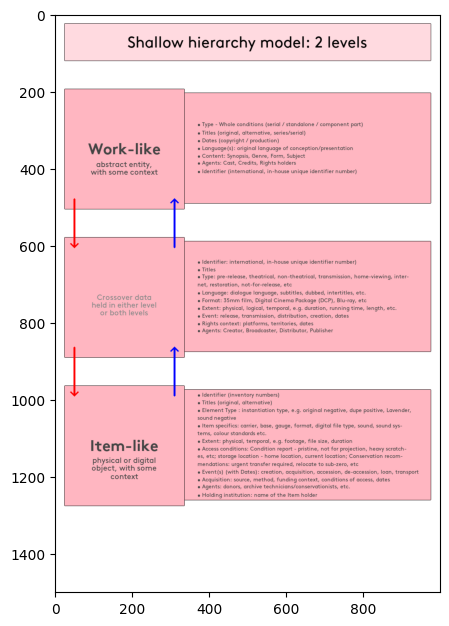

In [87]:

img_path = pathlib.Path.cwd() / '0.2.1-C.png'

canvas_w, canvas_h = 1000, 1500
canvas = numpy.zeros((canvas_h, canvas_w, 3), numpy.uint8)
canvas[:, :] = (255, 255, 255)

elements = dict()
draw_rectangle('header', 25, 25, 950, 95, ((193/2)+(255/2),(182/2)+(255/2),(255/2)+(255/2)))

box_colour = (193, 182, 255)
# 255, 182, 193
draw_rectangle('layer_1', 125, 155+50, 850, 285, box_colour)
# draw_rectangle('layer_2', 125, 490, 850, 285, box_colour)
draw_rectangle('layer_3', 125, 490+(50*2), 850, 285, box_colour)
draw_rectangle('layer_4', 125, 825+(50*3), 850, 285, box_colour)

# draw_rectangle('box_1_shadow', 25+5, 145+5, 300, 300, (0, 0, 0))

draw_rectangle('box_1', 25, 145+50, 310, 310, box_colour)
# draw_rectangle('box_2', 125, 480, 310, 310, box_colour)
draw_rectangle('box_3', 25, 480+50+50, 310, 310, box_colour)
draw_rectangle('box_4', 25, 815+50+50+50, 310, 310, box_colour)

# TODO and dotted line for blue.

# cv2.line(canvas, (25+25,(145+310)-25), (25+25, 815+25), (0,0,255), 4)
instep = 25+25
cv2.arrowedLine(canvas, (instep,(145+50+310)-25), (instep, 480+50+50+25), (0,0,255), 4)
cv2.arrowedLine(canvas, (instep,(480+50+50+310)-25), (instep, 815+50+50+50+25), (0,0,255), 4)


cv2.arrowedLine(canvas,  (310, 480+50+50+25), (310,(145+50+310)-25), (255,0,0), 4)
cv2.arrowedLine(canvas, (310, 815+50+50+50+25), (310,(480+50+50+310)-25), (255,0,0), 4)



# cv2.arrowedLine(canvas, (instep,(815+310)-25), (instep, 1150+25), (0,0,255), 4)
# cv2.arrowedLine(canvas, (310,(145+310)-25), (310, 480+25), (255,0,0), 4)
# cv2.arrowedLine(canvas, (310,(480+310)-25), (310, 815+25), (255,0,0), 4)

cv2.imwrite(img_path, canvas)

image_data = Image.open(img_path)
draw = ImageDraw.Draw(image_data)

draw_text_by_anchor('header', 'Shallow hierarchy model: 2 levels', 'Regular', 40, True, 0, 0, "#000000", 1, 0)

# mathematically calculate offsets.

layer_1_text = [
    
    # '• Type - Whole conditions (serial / standalone / component part)',
    # '• Identifier (international, in-house unique identifier number)',
    # '• Titles (original, alternative, series/serial)',
    # '• Country (production country/countries)',
    # '• Dates (copyright / production)',
    # '• Language(s): original language of conception/presentation',
    # '• Notes/History',
    # '• Content: Synopsis, Genre, Form, Subject',
    # '• Agents: Cast, Credits, Rights holders'
    
    
    
    
'• Type - Whole conditions (serial / standalone / component part)',
'• Titles (original, alternative, series/serial)',
'• Dates (copyright / production)',
'• Language(s): original language of conception/presentation',
'• Content: Synopsis, Genre, Form, Subject',
'• Agents: Cast, Credits, Rights holders',
'• Identifier (international, in-house unique identifier number)',
    
    
    ]

layer_1_text = [{'text':x, 'offset':i-((len(layer_1_text)-1)/2)} for i,x in enumerate(layer_1_text)]
for x in layer_1_text:
    draw_text_by_anchor('layer_1', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

# layer_2_text = [
#     '• Type - Whole conditions (serial / standalone / component part)',
#     '• Identifier (international, in-house unique identifier number)',
#     '• Titles (original, alternative, series/serial)',
#     '• Country (production country/countries)',
#     '• Dates (copyright / production)',
#     '• Language(s)',
#     '• Notes/History',
#     '• Content: Synopsis, Genre, Form, Subject',
#     '• Agents: Cast, Credits, Rights holders'
# ]

# layer_2_text = [{'text':x, 'offset':i-((len(layer_2_text)-1)/2)} for i,x in enumerate(layer_2_text)]
# for x in layer_2_text:
#     draw_text_by_anchor('layer_2', x['text'], 'Regular', 14, False, x['offset'], -80, "#444444")

layer_3_text = [


    
    # '• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing, inter-',
    # 'net, restoration, not-for-release, etc',
    # '• Identifier (international, in-house unique identifier number)',
    # '• Titles',
    # '• Language(s): language of dialogue, subtitles, dubbing, intertitles, etc.',
    # '• Format: 35mm film, Digital Cinema Package (DCP), Blu-ray, etc',
    # '• Extent: physical, logical, temporal, e.g. duration, running time, length, etc.',
    # '• Event: release, transmission, distribution, creation, dates',
    # '• Rights context: platforms, territories, dates',
    # '• Agents: Creator, Broadcaster, Distributor, Publisher'


'• Identifier: international, in-house unique identifier number)',
'• Titles',
'• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing, inter-',
'net, restoration, not-for-release, etc',
'• Language: dialogue language, subtitles, dubbed, intertitles, etc.',
'• Format: 35mm film, Digital Cinema Package (DCP), Blu-ray, etc',
'• Extent: physical, logical, temporal, e.g. duration, running time, length, etc.',
'• Event: release, transmission, distribution, creation, dates',
'• Rights context: platforms, territories, dates',
'• Agents: Creator, Broadcaster, Distributor, Publisher',


]

layer_3_text = [{'text':x, 'offset':i-((len(layer_3_text)-1)/2)} for i,x in enumerate(layer_3_text)]
for x in layer_3_text:
    draw_text_by_anchor('layer_3', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

layer_4_text = [


    # '• Identifier (inventory numbers)',
    # '• Titles (original, alternative)',
    # '• Element Type : instantiation type, e.g. original negative, dupe positive, Lavender,',
    # 'sound negative',
    # '• Item specifics: carrier, base, gauge, format, digital file type, sound, sound sys-',
    # 'tems, colour standards etc.',
    # '• Extent: physical, temporal, e.g. footage, file size, duration',
    # '• Access conditions: Condition report - pristine, not for projection, heavy scratch-',
    # 'es, etc; storage location - home location, current location; Conservation recom-',
    # 'mendations: urgent transfer required, relocate to sub-zero, etc',
    # '• Event(s) (with Dates): creation, acquisition, accession, de-accession, loan, transport',
    # '• Acquisition: source, method, funding context, conditions of access, dates',
    # '• Agents: donors, archive technicians/conservationists, etc.',
    # '• Holding institution: name of the Item holder'

'• Identifier (inventory numbers)',
'• Titles (original, alternative)',
'• Element Type : instantiation type, e.g. original negative, dupe positive, Lavender,',
'sound negative',
'• Item specifics: carrier, base, gauge, format, digital file type, sound, sound sys-',
'tems, colour standards etc.',
'• Extent: physical, temporal, e.g. footage, file size, duration',
'• Access conditions: Condition report - pristine, not for projection, heavy scratch-',
'es, etc; storage location - home location, current location; Conservation recom-',
'mendations: urgent transfer required, relocate to sub-zero, etc',
'• Event(s) (with Dates): creation, acquisition, accession, de-accession, loan, transport',
'• Acquisition: source, method, funding context, conditions of access, dates',
'• Agents: donors, archive technicians/conservationists, etc.',
'• Holding institution: name of the Item holder',

]

layer_4_text = [{'text':x, 'offset':i-((len(layer_4_text)-1)/2)} for i,x in enumerate(layer_4_text)]
for x in layer_4_text:
    draw_text_by_anchor('layer_4', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

draw_text_by_anchor('box_1', 'Work-like', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_1', 'abstract entity,', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_1', 'with some context', 'Regular', 20, True, 3, 0, "#444444", 1, 0)


# draw_text_by_anchor('box_2', 'Variant', 'Bold', 40, True, 0, 0, "#444444")
# draw_text_by_anchor('box_2', 'abstract entity', 'Regular', 20, True, 2, 0, "#444444")
# draw_text_by_anchor('box_2', 'optional', 'Regular', 20, True, 3.5, 0, "blue")

# draw_text_by_anchor('box_3', 'Manifestation', 'Bold', 40, True, 0, 0, "#444444")
draw_text_by_anchor('box_3', 'Crossover data', 'Regular', 20, True, 0, 0, "#888888", 1, 0)
draw_text_by_anchor('box_3', 'held in either level', 'Regular', 20, True, 1, 0, "#888888", 1, 0)
draw_text_by_anchor('box_3', 'or both levels', 'Regular', 20, True, 2, 0, "#888888", 1, 0)


# Crossover data
# held in either level
# or both levels

draw_text_by_anchor('box_4', 'Item-like', 'Bold', 40, True, 0, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'physical or digital', 'Regular', 20, True, 2, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'object, with some', 'Regular', 20, True, 3, 0, "#444444", 1, 0)
draw_text_by_anchor('box_4', 'context', 'Regular', 20, True, 4, 0, "#444444", 1, 0)



image_data.save(img_path)

render_preview(img_path)

(1500, 1000, 3)


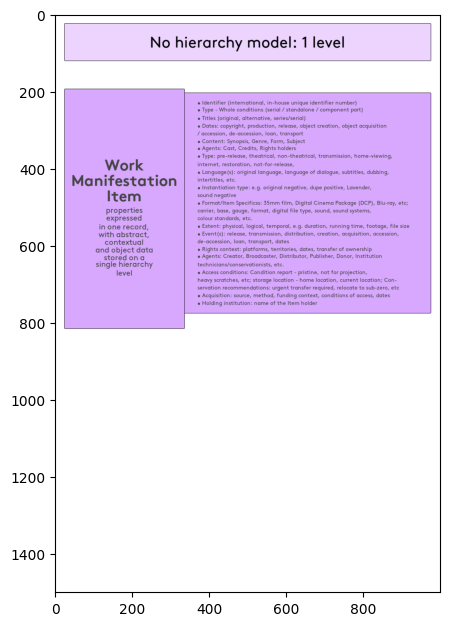

In [84]:

img_path = pathlib.Path.cwd() / '0.2.1-D.png'

canvas_w, canvas_h = 1000, 1500
canvas = numpy.zeros((canvas_h, canvas_w, 3), numpy.uint8)
canvas[:, :] = (255, 255, 255)

elements = dict()

draw_rectangle('header', 25, 25, 950, 95, ((255/2)+(255/2),(168/2)+(255/2),(216/2)+(255/2)))


box_colour = (255, 168, 216)
draw_rectangle('layer_1', 125, 155+50, 850, 285*2, box_colour)

draw_rectangle('box_1', 25, 145+50, 310, 310*2, box_colour)

cv2.imwrite(img_path, canvas)

image_data = Image.open(img_path)
draw = ImageDraw.Draw(image_data)

draw_text_by_anchor('header', 'No hierarchy model: 1 level', 'Regular', 40, True, 0, 0, "#000000", 1, 0)

# mathematically calculate offsets.

layer_1_text = [
    
 
'• Identifier (international, in-house unique identifier number)',
'• Type - Whole conditions (serial / standalone / component part)',
'• Titles (original, alternative, series/serial)',
'• Dates: copyright, production, release, object creation, object acquisition',
'/ accession, de-accession, loan, transport',
'• Content: Synopsis, Genre, Form, Subject',
'• Agents: Cast, Credits, Rights holders',
'• Type: pre-release, theatrical, non-theatrical, transmission, home-viewing,',
'internet, restoration, not-for-release,',
'• Language(s): original language, language of dialogue, subtitles, dubbing,',
'intertitles, etc.',
'• Instantiation type: e.g. original negative, dupe positive, Lavender,',
'sound negative',
'• Format/Item Specificss: 35mm film, Digital Cinema Package (DCP), Blu-ray, etc;',
'carrier, base, gauge, format, digital file type, sound, sound systems,',
'colour standards, etc.',
'• Extent: physical, logical, temporal, e.g. duration, running time, footage, file size',
'• Event(s): release, transmission, distribution, creation, acquisition, accession,',
'de-accession, loan, transport, dates',
'• Rights context: platforms, territories, dates, transfer of ownership',
'• Agents: Creator, Broadcaster, Distributor, Publisher, Donor, Institution',
'technicians/conservationists, etc.',
'• Access conditions: Condition report - pristine, not for projection,',
'heavy scratches, etc; storage location - home location, current location; Con-',
'servation recommendations: urgent transfer required, relocate to sub-zero, etc',
'• Acquisition: source, method, funding context, conditions of access, dates',
'• Holding institution: name of the Item holder',
    
    
    
    
    ]

layer_1_text = [{'text':x, 'offset':i-((len(layer_1_text)-1)/2)} for i,x in enumerate(layer_1_text)]
for x in layer_1_text:
    draw_text_by_anchor('layer_1', x['text'], 'Regular', 14, False, x['offset'], -180, "#444444", 1, 0)

# TODO
# the by_anchor method worked great when font was predictable
# but the need to have text of different fontsize co-existing means pre-compute, so now you are supporting both methods.
# instead, switch everything to pre-compute and dynamic centering, and make background rects match that.


bbox_array = list()
bbox_array.append(draw_text_by_anchor('box_1', 'Work', 'Bold', 40, True, 0, 0, (68,68,68, 0), 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'Manifestation', 'Bold', 40, True, 2, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'Item', 'Bold', 40, True, 4, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'properties', 'Regular', 20, True, 6, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'expressed', 'Regular', 20, True, 7, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'in one record,', 'Regular', 20, True, 8, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'with abstract,', 'Regular', 20, True, 9, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'contextual', 'Regular', 20, True, 10, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'and object data', 'Regular', 20, True, 11, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'stored on a', 'Regular', 20, True, 12, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'single hierarchy', 'Regular', 20, True, 13, 0, "#444444", 0, 0))
bbox_array.append(draw_text_by_anchor('box_1', 'level', 'Regular', 20, True, 14, 0, "#444444", 0, 0))

df = pandas.DataFrame(bbox_array, columns=['x1', 'y1', 'x2', 'y2'])
test_mid = ((min(df.y1)+max(df.y1))/2)
box_mid =  ((145+50+310*2)/2)
y_adjust = (box_mid - test_mid)/2
 

draw_text_by_anchor('box_1', 'Work', 'Bold', 40, True, 0, 0, (68,68,68, 0), 1, y_adjust)
draw_text_by_anchor('box_1', 'Manifestation', 'Bold', 40, True, 2, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'Item', 'Bold', 40, True, 4, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'properties', 'Regular', 20, True, 6, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'expressed', 'Regular', 20, True, 7, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'in one record,', 'Regular', 20, True, 8, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'with abstract,', 'Regular', 20, True, 9, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'contextual', 'Regular', 20, True, 10, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'and object data', 'Regular', 20, True, 11, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'stored on a', 'Regular', 20, True, 12, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'single hierarchy', 'Regular', 20, True, 13, 0, "#444444", 1, y_adjust)
draw_text_by_anchor('box_1', 'level', 'Regular', 20, True, 14, 0, "#444444", 1, y_adjust)



image_data.save(img_path)

render_preview(img_path)

# print(len(test))
# test.head()